## This is some code to generate biomass estimates from UAV data

1. Perform Tree segmentation to get separate all the individual trees
    a. across the entire plot
    b. within GEDI footprints only

2. Retreive and Store Tree height and canopy cover information for each tree
    a. across the entire plot
    b. within the GEDI footprints

2a. get tree specific height comparison info for trees vs ground measurements

3. Find algorithms to interpolate tree info to biomass

4. generate biomass estimates



In [3]:
# imports 
# may need to run this in command line because packages are not available in R 4.6.1
#install.packages(c('terra', 'sf', 'lidR', 'rlas', 'dplyr', 'geojsonio'), repos='https://cran.r-project.org')

library(terra)
library(sf)
library(lidR)
library(dplyr)

Please select your clipped CHM file in the file browser.



Selected file: C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\R code\Output Files\chm_0.4m_clipped.tif 
Simple feature collection with 814 features and 2 fields
Attribute-geometry relationships: constant (2)
Geometry type: POINT
Dimension:     XYZ
Bounding box:  xmin: 712406.2 ymin: 3909891 xmax: 712689 ymax: 3910059
z_range:       zmin: 2.015002 zmax: 23.83
Projected CRS: WGS 84 / UTM zone 10N
First 10 features:
   treeID        Z                       geometry
1       1 2.088000 POINT Z (712465 3910059 2.088)
2       2 3.022999 POINT Z (712467.4 3910058 3...
3       3 3.229001 POINT Z (712469.8 3910056 3...
4       4 4.928998 POINT Z (712477.8 3910054 4...
5       5 3.724000 POINT Z (712479.8 3910053 3...
6       6 2.890003 POINT Z (712482.6 3910052 2...
7       7 2.042001 POINT Z (712471.8 3910045 2...
8       8 9.918000 POINT Z (712467.4 3910044 9...
9       9 8.096998 POINT Z (712463.4 3910043 8...
10     10 6.205002 POINT Z (712473.8 39100

Please select your GEDI footprints clipped shapefile.



Reading layer `arb_bio_test_2_gedi_footprints_clipped' from data source 
  `C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Notebook_Test1_Arb_Output_Files\arb_bio_test_2_gedi_footprints_clipped.geojson' 
  using driver `GeoJSON'
Simple feature collection with 6 features and 26 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -120.6631 ymin: 35.31012 xmax: -120.6614 ymax: 35.31092
Geodetic CRS:  WGS 84


CRS mismatch detected — reprojecting footprints to match CHM...

Warning message:
"attribute variables are assumed to be spatially constant throughout all geometries"


reading_order_id,tree_count
<int>,<int>
1,20
2,8
3,13
4,15
5,22
6,12


Layer treetops in dataset treetops.gpkg already exists:
use either append=TRUE to append to layer or append=FALSE to overwrite layer


ERROR: Error: Dataset already exists.



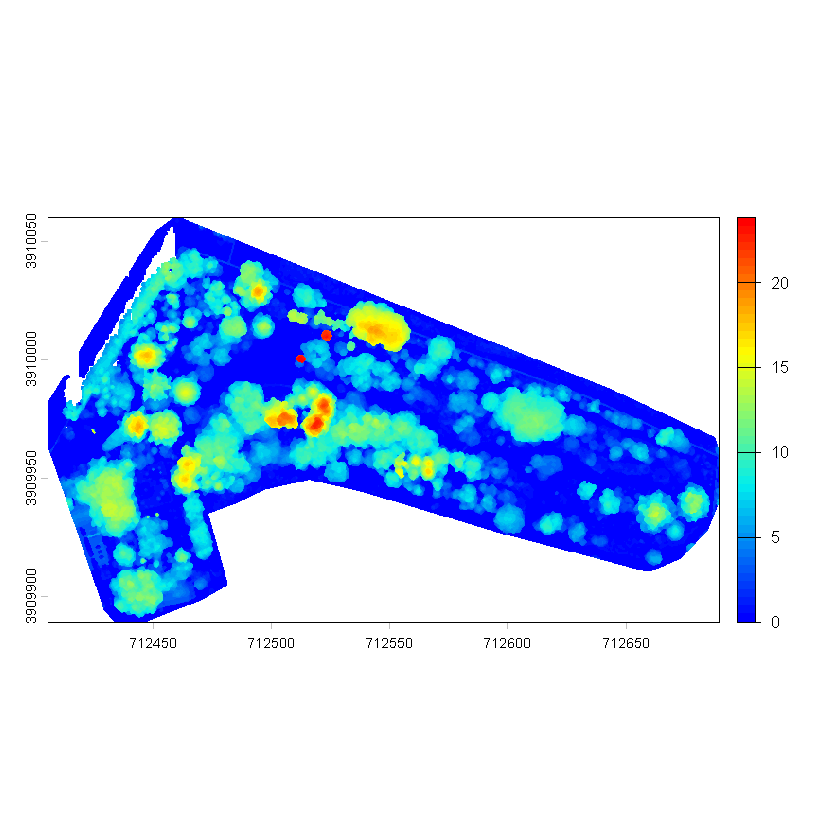

In [4]:

# Load CHM
message("Please select your clipped CHM file in the file browser.")
chm_clipped_path <- file.choose()
cat("Selected file:", chm_clipped_path, "\n")
chm_clipped <- rast(chm_clipped_path)

#set some color palettes
col <- height.colors(50)
col1 <- pastel.colors(900)

# Generate kernel and smooth chm
kernel <- matrix(1, 3, 3)
schm <- terra::focal(x = chm_clipped, w = kernel, fun = median, na.rm = TRUE)
plot(schm, col = col)

# Detect trees
ttops <- locate_trees(las = schm, algorithm = lmf(ws = 2.5))
print(ttops)

# Load GEDI footprints
message("Please select your GEDI footprints clipped shapefile.")
footprint_path <- file.choose()
footprints <- st_read(footprint_path)

# Check and align CRS
if (st_crs(footprints) != st_crs(ttops)) {
  message("CRS mismatch detected — reprojecting footprints to match CHM...")
  footprints <- st_transform(footprints, st_crs(ttops))
} else {
  message("CRS match confirmed.")
}

# Filter to only trees within footprints
ttops_in_footprints <- st_intersection(ttops, footprints)

# Count trees per footprint
tree_counts <- ttops_in_footprints |>
  st_drop_geometry() |>
  group_by(reading_order_id) |>
  summarise(tree_count = n())

tree_counts

# Store the Height data for each segmented tree
# Extract ttops Z coordinate where height data is stored: ttops = treeID, geometry (X, Y, Z)
ttops$height <- st_coordinates(ttops)[, "Z"]

# Save as a shapefile or geopackage to keep geometry + attributes together
st_write(ttops, "treetops.gpkg")

# Recreate clean data frame with tree ID, location, and height to load into Excel sheet
tree_data <- data.frame(
  treeID   = ttops$treeID,
  x        = st_coordinates(ttops)[, "X"],
  y        = st_coordinates(ttops)[, "Y"],
  height_m = st_coordinates(ttops)[, "Z"]
)
tree_data
# Save to CSV if you want to persist it
write.csv(tree_data, "tree_heights.csv", row.names = FALSE)

# Plot
plot(chm_clipped, col = col, main = "Detected Trees within Footprints")
plot(st_geometry(footprints), border = "black", add = TRUE)
plot(st_geometry(ttops_in_footprints), add = TRUE, pch = 3, col = "red", cex = 0.5)